In [32]:
%load_ext autoreload
%autoreload 2

In [33]:
import torch
from GCN import GCN
from GraphSAGE import GraphSAGE
from GAT import GAT
from torch_geometric.datasets import WebKB
from torch_geometric.loader import DataLoader
import numpy as np
import random
import time
from sklearn.metrics import f1_score, accuracy_score


In [34]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

cuda


In [35]:
## Instantiate the ExperimentTracker
from results_manager import ExperimentTracker

tracker = ExperimentTracker(dataset_name="Cornell", node_feature_type="PyG")

In [36]:
args = {
      'device': device,
      'num_layers': 3,
      'hidden_dim': 256,
      'dropout': 0.3,
      'lr': 0.01,
      'epochs': 100,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 0,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      #heads for GAT
      'heads': 2,
      'split_idx': 0
  }

In [37]:
dataset = WebKB(root ='tmp/Cornell', name='Cornell')

In [38]:
num_features = dataset.num_features
num_classes = dataset.num_classes
num_nodes = dataset[0].num_nodes
num_edges = dataset[0].num_edges

print(f"Number of graphs in dataset: {len(dataset)}")
print(f"Number of features for each node: {num_features}")
print(f"Number of num_classes : {num_classes}")

print(f"Number of num_nodes : {num_nodes}")
print(f"Number of num_edges : {num_edges}")

Number of graphs in dataset: 1
Number of features for each node: 1703
Number of num_classes : 5
Number of num_nodes : 183
Number of num_edges : 298


In [39]:
def train(model, data, optimizer, criterion):
    """
    one training epoch
    model -  GNN (GCNConv or GraphSAGE)
    data - Entire Graph Dataset i.e. dataset[0]
    optimizer - algorithm that updates model weights (Adam, SGD, etc.)
    criterion - loss function (often BCEWithLogitsLoss for the PPI dataset)
    """
    #Training mode
    model.train()
    #TODO: Move the data to device outside the training loop
    #data = data.to(device)
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    split_idx = args['split_idx']
    loss = criterion(out[data.train_mask[:,split_idx]], data.y[data.train_mask[:,split_idx]])
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def test(model, data, mask, return_preds=False):
    """
    data: dataset[0] - 1 entire graph composed of all labeled train, test, val
    mask: array of [True, False, ....]
    """
    #switch to evaluation mode
    model.eval()
    # ys: Ground Truth Labels, preds: model predictions across all batches
    ys, preds = [], []

    with torch.no_grad():
        out = model(data.x, data.edge_index)
    pred = out[mask].argmax(dim=1).cpu().numpy()
    y = data.y[mask].cpu().numpy()
    
    #macro - how model handles small classes
    f1 = f1_score(y, pred, average='macro', zero_division=0)
    acc = accuracy_score(y, pred)
    if return_preds:
        return f1, acc, y, pred
    return f1, acc
        

In [41]:
def train_and_evaluate(model, data, optimizer, scheduler, criterion, model_name, epochs=100):
    best_val_f1 = 0
    train_losses, val_f1s, val_accs, test_f1s, test_accs = [],[],[],[],[]
    training_time = 0

    for epoch in range(1, epochs+1):
        start_time = time.time()

        loss = train(model, data, optimizer, criterion)
        
        if scheduler:
            scheduler.step()

        epoch_time = time.time() - start_time
        training_time += epoch_time

        split_idx = args['split_idx']
        val_f1, val_acc = test(model, data, data.val_mask[:,split_idx])
        test_f1, test_acc = test(model, data, data.test_mask[:,split_idx])

        train_losses.append(loss)
        val_f1s.append(val_f1)
        test_f1s.append(test_f1)
        val_accs.append(val_acc)
        test_accs.append(test_acc)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), 'best_model_gcn.pth')

        tracker.log_epoch(model_name=model_name, epoch=epoch, loss=loss, val_f1=val_f1, val_acc=val_acc)
        if epoch % 10 == 0:
            print(f"Epoch: {epoch:03d}, "
                f"Loss: {loss:.4f}, "
                f"Val F1: {val_f1:.4f},"
                f"Val Acc: {val_acc:.4f}, "
                f"Time: {epoch_time:.2f}s"
                )


    model.load_state_dict(torch.load('best_model_gcn.pth', map_location=device))
    test_f1, test_acc, y_true, y_pred = test(model, data, data.test_mask[:,split_idx], return_preds=True)
    #test_f1, test_acc = test(model, data, data.test_mask[:,split_idx])
    print(f"Test F1: {test_f1:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalize

    plt.figure(figsize=(5, 5))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=range(5), yticklabels=range(5))
    plt.title('Normalized Confusion Matrix: Roman Empire Syntactic Roles')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()
    
    tracker.save_results(
        model_name=model_name, 
        test_f1=test_f1, 
        test_acc=test_acc,
        params=args # Assuming 'args' contains your hyperparams
    )
    
    return model, train_losses, val_f1s, test_f1s, training_time

In [42]:
def build_optimizer(args, params):
    
    filter_fn = filter(lambda p : p.requires_grad, params)
    weight_decay = args['weight_decay']
    if args['opt'] == 'adam':
        optimizer = torch.optim.Adam(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    elif args['opt'] == 'sgd':
        optimizer = torch.optim.SGD(filter_fn, lr=args['lr'], momentum=0.95, weight_decay=weight_decay)
    elif args['opt'] == 'rmsprop':
        optimizer = torch.optim.RMSprop(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    elif args['opt'] == 'adagrad':
        optimizer = torch.optim.Adagrad(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    if args['opt_scheduler'] == 'none':
        return None, optimizer
    elif args['opt_scheduler'] == 'step':
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=args['opt_decay_step'], gamma=args['opt_decay_rate'])
    elif args['opt_scheduler'] == 'cos':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args['opt_restart'])
    return scheduler, optimizer

In [43]:
import matplotlib.pyplot as plt
def plot_results(results, title, label, ylabel):
    plt.figure(figsize=(3,2))
    epochs = range(1, len(results)+1)
    plt.plot(epochs, results, label = label)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()

In [44]:
def gcn_run():
    model = GCN(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="GCN",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GCN','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GCN','F1 Score')


Training GCN
Epoch: 010, Loss: 0.7140, Val F1: 0.2696,Val Acc: 0.3390, Time: 0.00s
Epoch: 020, Loss: 0.4350, Val F1: 0.2915,Val Acc: 0.4407, Time: 0.00s
Epoch: 030, Loss: 0.3435, Val F1: 0.2692,Val Acc: 0.4407, Time: 0.00s
Epoch: 040, Loss: 0.3065, Val F1: 0.2771,Val Acc: 0.4237, Time: 0.00s
Epoch: 050, Loss: 0.2661, Val F1: 0.2641,Val Acc: 0.4407, Time: 0.00s
Epoch: 060, Loss: 0.2167, Val F1: 0.2920,Val Acc: 0.4746, Time: 0.00s
Epoch: 070, Loss: 0.1855, Val F1: 0.2850,Val Acc: 0.4576, Time: 0.00s
Epoch: 080, Loss: 0.1427, Val F1: 0.2800,Val Acc: 0.4407, Time: 0.00s
Epoch: 090, Loss: 0.1233, Val F1: 0.2906,Val Acc: 0.4407, Time: 0.00s
Epoch: 100, Loss: 0.1264, Val F1: 0.2917,Val Acc: 0.4407, Time: 0.00s
Test F1: 0.2337
Test Accuracy: 0.3243


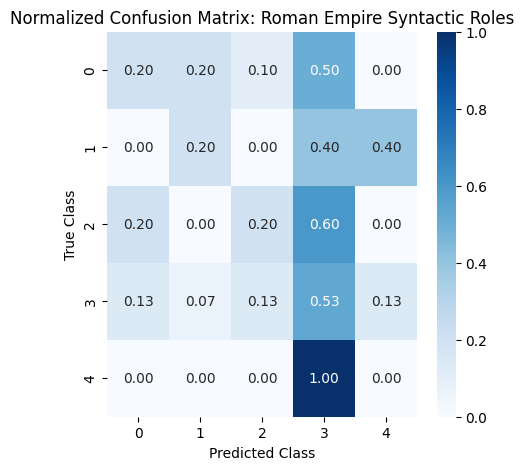

GCN results saved using PyG features.
Training Time 0.46567726135253906


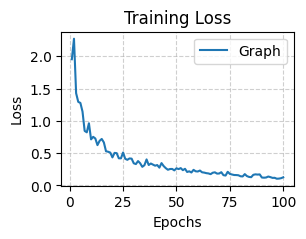

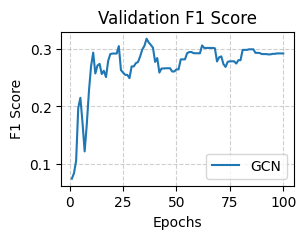

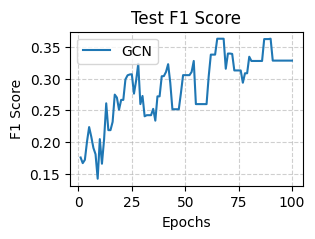

In [45]:
gcn_run()

In [46]:
def graphSage_run():
    model = GraphSAGE(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    data = dataset[0].to(device)
    print("Training Graph SAGE")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data,
        optimizer,
        scheduler, 
        criterion,
        model_name="GraphSAGE", 
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'GraphSAGE','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GraphSAGE','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GraphSAGE','F1 Score')


Training Graph SAGE
Epoch: 010, Loss: 0.7613, Val F1: 0.4809,Val Acc: 0.6441, Time: 0.00s
Epoch: 020, Loss: 0.0693, Val F1: 0.5854,Val Acc: 0.6949, Time: 0.00s
Epoch: 030, Loss: 0.0409, Val F1: 0.5627,Val Acc: 0.6610, Time: 0.00s
Epoch: 040, Loss: 0.0074, Val F1: 0.5274,Val Acc: 0.6949, Time: 0.00s
Epoch: 050, Loss: 0.0027, Val F1: 0.5325,Val Acc: 0.6949, Time: 0.00s
Epoch: 060, Loss: 0.0037, Val F1: 0.5485,Val Acc: 0.7119, Time: 0.00s
Epoch: 070, Loss: 0.0017, Val F1: 0.5459,Val Acc: 0.7119, Time: 0.00s
Epoch: 080, Loss: 0.0013, Val F1: 0.5791,Val Acc: 0.7458, Time: 0.00s
Epoch: 090, Loss: 0.0013, Val F1: 0.5841,Val Acc: 0.7458, Time: 0.00s
Epoch: 100, Loss: 0.0004, Val F1: 0.5674,Val Acc: 0.7288, Time: 0.00s
Test F1: 0.4246
Test Accuracy: 0.5946


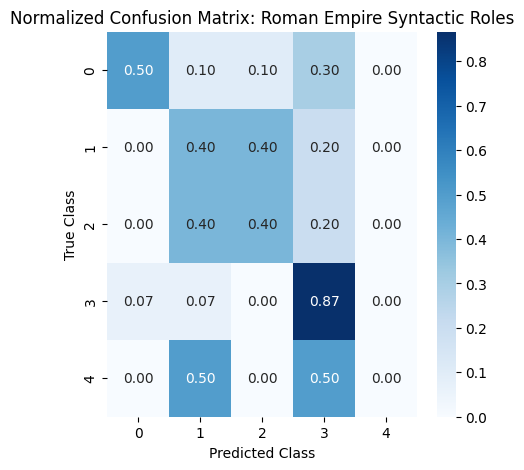

GRAPHSAGE results saved using PyG features.
Training Time 0.4042544364929199


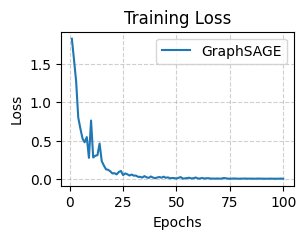

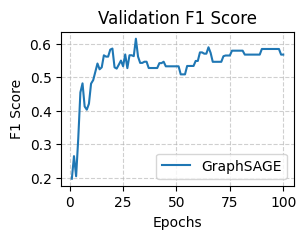

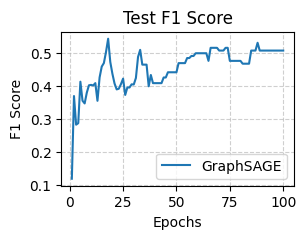

In [47]:
graphSage_run()

In [48]:
def gat_run():
    model = GAT(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'],
                heads=args['heads'],
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    data = dataset[0].to(device)
    print("Training GAT")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion,
        model_name="GAT", 
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'GAT','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GAT','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GAT','F1 Score')


Training GAT
Epoch: 010, Loss: 1.3823, Val F1: 0.2178,Val Acc: 0.4915, Time: 0.01s
Epoch: 020, Loss: 1.2702, Val F1: 0.2817,Val Acc: 0.5254, Time: 0.01s
Epoch: 030, Loss: 1.0730, Val F1: 0.2807,Val Acc: 0.5424, Time: 0.01s
Epoch: 040, Loss: 1.0517, Val F1: 0.2232,Val Acc: 0.5254, Time: 0.01s
Epoch: 050, Loss: 1.1007, Val F1: 0.1827,Val Acc: 0.4915, Time: 0.01s
Epoch: 060, Loss: 1.1274, Val F1: 0.1317,Val Acc: 0.4576, Time: 0.01s
Epoch: 070, Loss: 0.9199, Val F1: 0.1778,Val Acc: 0.4576, Time: 0.01s
Epoch: 080, Loss: 0.9413, Val F1: 0.1814,Val Acc: 0.4407, Time: 0.01s
Epoch: 090, Loss: 1.0626, Val F1: 0.2478,Val Acc: 0.4915, Time: 0.01s
Epoch: 100, Loss: 0.9459, Val F1: 0.2351,Val Acc: 0.4746, Time: 0.01s
Test F1: 0.3438
Test Accuracy: 0.4324


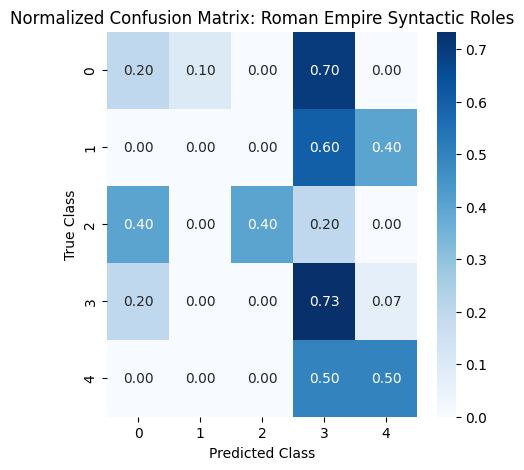

GAT results saved using PyG features.
Training Time 0.7304074764251709


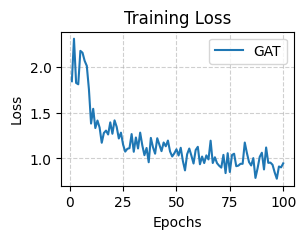

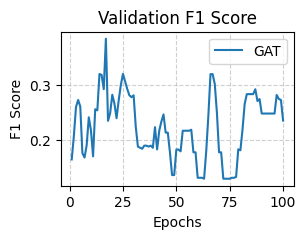

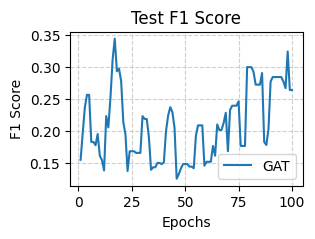

In [49]:
gat_run()

In [50]:
from GCN2 import GCN2

In [51]:
args = {
      'device': device,
      'num_layers': 10,
      'hidden_dim': 256,
      'dropout': 0.5,
      'lr': 0.001,
      'epochs': 400,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 5e-4,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      'alpha': 0.1,
      'theta':0.5,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 1
  }

In [52]:
def gcn2_run():
    model = GCN2(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout'], alpha=args['alpha'], theta=args['theta']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="GCN2",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GCN2','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GCN2','F1 Score')


Training GCN
Epoch: 010, Loss: 1.2806, Val F1: 0.1921,Val Acc: 0.5085, Time: 0.00s
Epoch: 020, Loss: 0.9301, Val F1: 0.2354,Val Acc: 0.4746, Time: 0.01s
Epoch: 030, Loss: 0.6865, Val F1: 0.1955,Val Acc: 0.4576, Time: 0.00s
Epoch: 040, Loss: 0.5425, Val F1: 0.3101,Val Acc: 0.4915, Time: 0.00s
Epoch: 050, Loss: 0.2939, Val F1: 0.3468,Val Acc: 0.5593, Time: 0.00s
Epoch: 060, Loss: 0.1611, Val F1: 0.4314,Val Acc: 0.5593, Time: 0.01s
Epoch: 070, Loss: 0.0859, Val F1: 0.4909,Val Acc: 0.6441, Time: 0.00s
Epoch: 080, Loss: 0.0557, Val F1: 0.5250,Val Acc: 0.6780, Time: 0.01s
Epoch: 090, Loss: 0.0277, Val F1: 0.4693,Val Acc: 0.6780, Time: 0.01s
Epoch: 100, Loss: 0.0125, Val F1: 0.4684,Val Acc: 0.6780, Time: 0.00s
Epoch: 110, Loss: 0.0076, Val F1: 0.5238,Val Acc: 0.7119, Time: 0.00s
Epoch: 120, Loss: 0.0077, Val F1: 0.5190,Val Acc: 0.6949, Time: 0.00s
Epoch: 130, Loss: 0.0022, Val F1: 0.5016,Val Acc: 0.6949, Time: 0.00s
Epoch: 140, Loss: 0.0024, Val F1: 0.5197,Val Acc: 0.6949, Time: 0.00s
Epoch: 

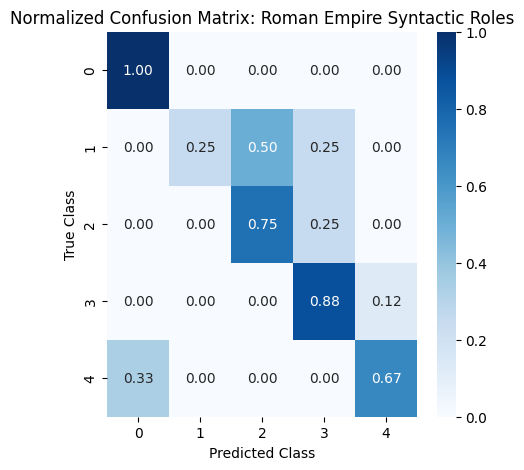

GCN2 results saved using PyG features.
Training Time 1.9968438148498535


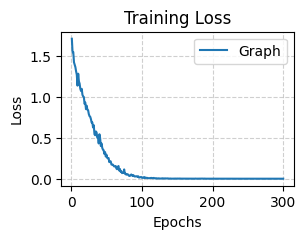

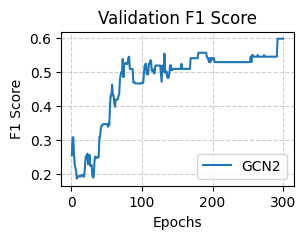

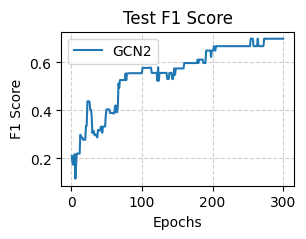

In [59]:
gcn2_run()

In [53]:
from H2GCN import H2GCN

In [57]:
args = {
      'device': device,
      'num_layers': 2, #Not applicable to H2GCN
      'hidden_dim': 30,
      'dropout': 0.5,
      'lr': 0.01,
      'epochs': 300,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 5e-4,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      'alpha': 0.1,
      'theta':0.5,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 1
  }

In [55]:
def h2GCN_run():
    model = H2GCN(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training H2GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="H2GCN",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'H2GCN','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'H2GCN','F1 Score')


Training H2GCN
Epoch: 010, Loss: 0.1319, Val F1: 0.4396,Val Acc: 0.7119, Time: 0.00s
Epoch: 020, Loss: 0.0424, Val F1: 0.5088,Val Acc: 0.7288, Time: 0.00s
Epoch: 030, Loss: 0.0113, Val F1: 0.4979,Val Acc: 0.7119, Time: 0.00s
Epoch: 040, Loss: 0.0262, Val F1: 0.4979,Val Acc: 0.7119, Time: 0.00s
Epoch: 050, Loss: 0.0058, Val F1: 0.4979,Val Acc: 0.7119, Time: 0.00s
Epoch: 060, Loss: 0.0066, Val F1: 0.5088,Val Acc: 0.7288, Time: 0.00s
Epoch: 070, Loss: 0.0059, Val F1: 0.5050,Val Acc: 0.7288, Time: 0.00s
Epoch: 080, Loss: 0.0043, Val F1: 0.4979,Val Acc: 0.7119, Time: 0.00s
Epoch: 090, Loss: 0.0025, Val F1: 0.4844,Val Acc: 0.6949, Time: 0.00s
Epoch: 100, Loss: 0.0042, Val F1: 0.5036,Val Acc: 0.7288, Time: 0.00s
Epoch: 110, Loss: 0.0032, Val F1: 0.5023,Val Acc: 0.7119, Time: 0.00s
Epoch: 120, Loss: 0.0034, Val F1: 0.5266,Val Acc: 0.7288, Time: 0.00s
Epoch: 130, Loss: 0.0030, Val F1: 0.5410,Val Acc: 0.7288, Time: 0.00s
Epoch: 140, Loss: 0.0038, Val F1: 0.5345,Val Acc: 0.7627, Time: 0.00s
Epoch

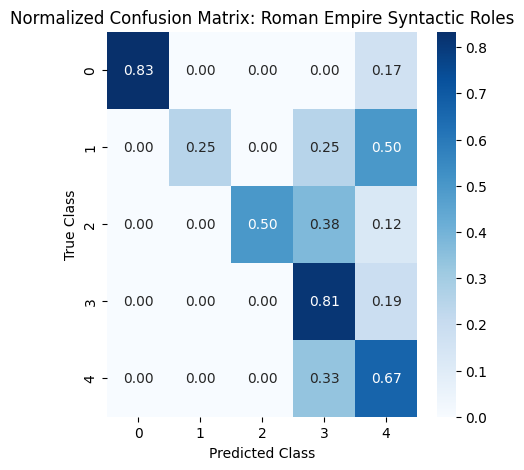

H2GCN results saved using PyG features.
Training Time 1.1837570667266846


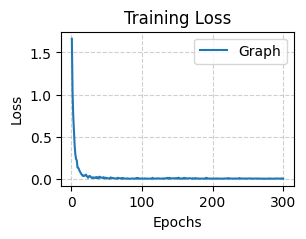

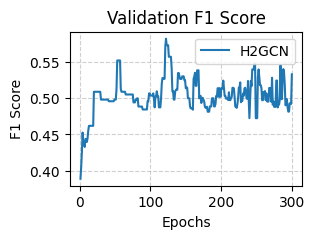

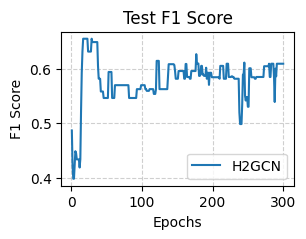

In [58]:
h2GCN_run()